### 설치된 라이브러리 버전 확인

In [1]:
import sys, platform
from importlib.metadata import version, PackageNotFoundError

def get_ver(pkg: str) -> str:
    try:
        return version(pkg)
    except PackageNotFoundError:
        return "not installed"

print("Python:", sys.version.split()[0])
print("OS:", platform.platform())
print("langgraph:", get_ver("langgraph"))
print("openai:", get_ver("openai"))
print("typing_extensions:", get_ver("typing_extensions"))

Python: 3.11.9
OS: macOS-14.6.1-x86_64-i386-64bit
langgraph: 1.0.4
openai: 2.8.1
typing_extensions: 4.15.0


### OpenAI API 사용

In [2]:
# 1) 루트 폴더에 .env 파일을 만들고 아래처럼 키를 적어둡니다.
#    OPENAI_API_KEY=sk-********************************
# 2) 필요시 설치: uv add python-dotenv openai

import os
from dotenv import load_dotenv
from openai import OpenAI

# .env 로딩
_ = load_dotenv()  # 기본적으로 현재 작업 디렉터리의 .env 탐색

# 환경변수에서 키 읽기 (dotenv가 주입)
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise RuntimeError(
        "환경변수 OPENAI_API_KEY가 없습니다. 프로젝트 루트에 .env 파일을 만들고 "
        "OPENAI_API_KEY=... 값을 넣은 뒤 다시 실행하세요."
    )

# OpenAI 기본 클라이언트 (공식 엔드포인트 사용, base_url 불필요)
client = OpenAI(api_key=api_key)

# 사용할 모델 (필요시 변경)
DEFAULT_MODEL = "gpt-4o-mini"

def chat_local(prompt: str, model: str = None, temperature: float = 0.2) -> str:
    """
    기존 노트북의 chat_local 함수를 OpenAI API 호출로 대체합니다.
    다른 셀 코드는 수정 없이 그대로 사용 가능합니다.
    """
    model = model or DEFAULT_MODEL
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature,
    )
    return (resp.choices[0].message.content or "").strip()

# 스모크 테스트
print(chat_local("한 줄로 인사해줘"))

안녕하세요! 오늘도 좋은 하루 되세요!


### Hello LangGraph

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

In [4]:
class S1(TypedDict):
    input: str      # key나 값을 입력하는 것이 아닌 어떤 데이터가 들어갈것인지 전달
    output: str

g1 = StateGraph(S1)

In [5]:
# 노드에서 사용할 에이전트
def echo_node(state: S1) -> S1:
    return {    # return 값은 state를 업데이트!
        "output": f"Echo: {state['input']}"
    } 

In [6]:
# 노드 생성
g1.add_node("echo", echo_node)

# 엣지 연결 생성
g1.add_edge(START, "echo")
g1.add_edge("echo", END)

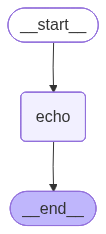

In [7]:
# Graph Compile -> 유효성 검사
app1 = g1.compile()

app1 # 그래프 출력

In [8]:
# invoke로 값 입력 후 실행
app1.invoke({"input": "LangGraph 첫 그래프!"})

{'input': 'LangGraph 첫 그래프!', 'output': 'Echo: LangGraph 첫 그래프!'}

### LLM node 추가

In [9]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

In [10]:
# State 정의
class S2(TypedDict):
    question: str
    answer: str

g2 = StateGraph(S2)

In [11]:
# 에이전트 정의
def echo_node(state: S2) -> S2:
    print("Echo Node ->", state)
    return {
        "question": f"Echo: {state['question']}"
    }

def llm_node(state: S2) -> S2:
    ans = chat_local(f"한 문장으로 답해줘: {state['question']}")
    print("LLM Node ->", state)
    return {"answer": ans}

In [12]:
# 노드 추가
g2.add_node("echo_node", echo_node)
g2.add_node("llm_node", llm_node)

# 엣지 연결 추가
g2.add_edge(START, "llm_node")
g2.add_edge("llm_node", "echo_node")
g2.add_edge("echo_node", END)

app2 = g2.compile()

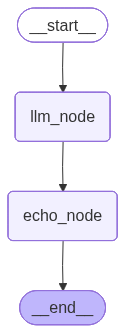

In [13]:
app2

In [14]:
app2.invoke({"question": "LangGraph는 무엇인가?"})

LLM Node -> {'question': 'LangGraph는 무엇인가?'}
Echo Node -> {'question': 'LangGraph는 무엇인가?', 'answer': 'LangGraph는 자연어 처리와 그래프 기반 데이터 구조를 결합하여 언어 이해 및 생성 작업을 지원하는 시스템입니다.'}


{'question': 'Echo: LangGraph는 무엇인가?',
 'answer': 'LangGraph는 자연어 처리와 그래프 기반 데이터 구조를 결합하여 언어 이해 및 생성 작업을 지원하는 시스템입니다.'}

### Conditional Edge

In [15]:
from typing_extensions import TypedDict

In [16]:
class S3(TypedDict):
    question: str
    result: str

In [17]:
def validate(state: S3) -> S3:
    q = (state.get("question" or "")).strip()
    return {"result": "빈 질문"}

def answer(state: S3) -> S3:
    q = state["question"]
    a = chat_local(f"간단히 답해줘: {q}")
    return {"result": a}

def route_fn(state: S3) -> S3:
    if not (state.get("question") or "").strip():
        return "empty"
    return "ok"

In [18]:
g3 = StateGraph(S3)

g3.add_node("validate", validate)
g3.add_node("answer", answer)

g3.add_edge(START, "validate")
g3.add_conditional_edges("validate", route_fn, {"empty": END, "ok": "answer"})
g3.add_edge("answer", END)

app3 = g3.compile()

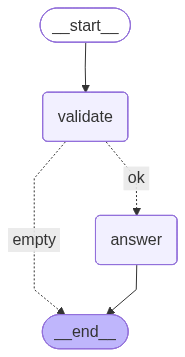

In [19]:
app3

In [30]:
print(app3.invoke({"question": ""}))
print(app3.invoke({"question": "Conditional Edge는 언제 쓰나?"}))

{'question': '', 'result': '빈 질문'}
{'question': 'Conditional Edge는 언제 쓰나?', 'result': 'Conditional Edge는 주로 그래프 데이터 구조에서 특정 조건에 따라 엣지를 추가하거나 제거할 때 사용됩니다. 예를 들어, 특정 조건이 만족될 때만 연결을 허용하거나, 특정 상황에서만 경로를 탐색할 때 유용합니다. 주로 알고리즘 최적화나 동적 그래프 처리에서 활용됩니다.'}


### Reducer(상태 합치기)

In [22]:
from typing_extensions import Annotated, TypedDict
import operator

In [23]:
class S4(TypedDict):
    topic: str
    facts: Annotated[list[str], operator.add] # 리스트를 합치는 규칙

In [24]:
def fact_a(state: S4) -> S4:
    t = state["topic"]
    return {"facts": [chat_local(f"{t}에 대한 핵심 사실 1가지를 1문장으로.", temperature=0.1)]}

def fact_b(state: S4) -> S4:
    t = state["topic"]
    return {"facts": [chat_local(f"{t}에 대한 추가 사실 1가지를 1문장으로.", temperature=0.1)]}


In [26]:
g4 = StateGraph(S4)

g4.add_node("fact_a", fact_a)
g4.add_node("fact_b", fact_b)

g4.add_edge(START, "fact_a")
g4.add_edge("fact_a", "fact_b")
g4.add_edge("fact_b", END)

app4 = g4.compile()

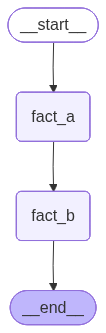

In [27]:
app4

In [28]:
app4.invoke({"topic": "LangGraph"})

{'topic': 'LangGraph',
 'facts': ['LangGraph는 자연어 처리와 그래프 기반 데이터 구조를 결합하여 언어 이해 및 생성 작업을 향상시키는 모델입니다.',
  'LangGraph는 자연어 처리와 그래프 기반 데이터 구조를 결합하여 언어 모델의 성능을 향상시키는 혁신적인 접근 방식입니다.']}

### Checkpoint, Streaming

In [32]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

In [34]:
# 이전 상태 재사용 가능한 간단 그래프
class S5(TypedDict):
    text: str
    steps: Annotated[list[str], operator.add]

In [36]:
def step1(state: S5) -> S5:
    return {"steps": [f"입력 길이: {len(state['text'])}"]}

def step2(state: S5) -> S5:
    s = chat_local(f"요약: {state['text']}")
    return {"steps": [f"요약완료({len(s)}자)"]}


In [40]:
g5 = StateGraph(S5)

g5.add_node("step1", step1)
g5.add_node("step2", step2)

g5.add_edge(START, "step1")
g5.add_edge("step1", "step2")
g5.add_edge("step2", END)

app5 = g5.compile(checkpointer=checkpointer)

thread = {"configurable": {"thread_id": "demo-1"}}

In [ ]:
print("== 1차 실행 ==")
for update in app5.stream({"text": "LangGraph는 상태+노드+엣지로 구성된 워크플로우 엔진."}, thread, stream_mode="values"):
    print(update)

print("== 2차 실행 (같은 thread_id)==")
for update in app5.stream({"text": "같은 스레드에서 두 번째 실행"}, thread, stream_mode="valuse"):
    print(update)

== 1차 실행 ==
{'text': 'LangGraph는 상태+노드+엣지로 구성된 워크플로우 엔진.', 'steps': []}
{'text': 'LangGraph는 상태+노드+엣지로 구성된 워크플로우 엔진.', 'steps': ['입력 길이: 34']}
{'text': 'LangGraph는 상태+노드+엣지로 구성된 워크플로우 엔진.', 'steps': ['입력 길이: 34', '요약완료(138자)']}
== 2차 실행 ==


### Send / Command

In [42]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
import operator

In [43]:
# 1) 상태: 리스트 병합 규칙 꼭 지정
class S(TypedDict):
    raw: str
    question: Annotated[list[str], operator.add]
    answer: Annotated[list[str], operator.add]

# 2) plan: 질문 리스트만 상태에 기록
def plan(state: S):
    qs = [p.strip()+"?" for p in state["raw"].split("?") if p.strip()]
    return {"question": qs}

# 3) fanout(조건 엣지 함수): qa로 Send 목록 변환 (핵심!)
def fanout(state: S):
    return [Send("qa", {"question": q}) for q in state["question"]]

# 4) qa: Send로 넘어온 입력(arg)에 'question'이 담겨옴
def qa(state: S) -> S:
    q = state.get("question", "")
    a = chat_local(f"아주 짧게 대답해줘: {q}", temperature=0.1) or ""
    return {"answer": [f"Q: {q} | A: {a.strip()}"]}

# 5) join: 마무리(패스스루)
def join(state: S) -> S:
    return {}

# 그래프 구성
g = StateGraph(S)
g.add_node("plan", plan)
g.add_node("qa", qa)
g.add_node("join", join)

g.add_edge(START, "plan")
# plan 다음 흐름을 '조건 엣지'로 정의 -> qa가 질문 수만큼 실행됨
g.add_conditional_edges("plan", fanout)
# qa 실행이 끝난 뒤 join으로 수집
g.add_edge("qa", "join")
g.add_edge("join", END)

app = g.compile()


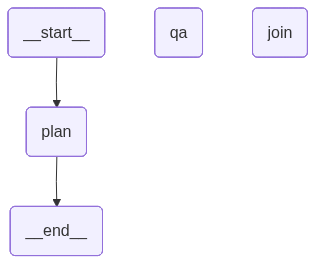

In [44]:
app

In [46]:
# 7) 실행
out = app.invoke({"raw": "LangGraph는 무엇인가? Conditional Edge는 언제 쓰나? Reducer는 왜 필요한가?"})
out

{'raw': 'LangGraph는 무엇인가? Conditional Edge는 언제 쓰나? Reducer는 왜 필요한가?',
 'question': ['LangGraph는 무엇인가?',
  'Conditional Edge는 언제 쓰나?',
  'Reducer는 왜 필요한가?'],
 'answer': ['Q: LangGraph는 무엇인가? | A: LangGraph는 자연어 처리(NLP)와 그래프 기반 데이터 구조를 결합한 모델로, 언어 이해와 생성에 도움을 주는 시스템입니다.',
  'Q: Conditional Edge는 언제 쓰나? | A: Conditional Edge는 특정 조건에 따라 그래프의 엣지를 활성화하거나 비활성화할 때 사용합니다.',
  'Q: Reducer는 왜 필요한가? | A: Reducer는 상태 관리를 단순화하고, 상태 변화를 예측 가능하게 하며, 애플리케이션의 상태를 일관되게 유지하기 위해 필요합니다.']}